Part 1 - Data Accuision: The EMNIST Letters dataset was loaded, an optional subset of about 10–20k images was sampled, images were converted and normalized to 28 x 28 grayscale, labels were verified to correspond to A–Z, and one real handwritten image (scanned or photographed) was set aside for testing.

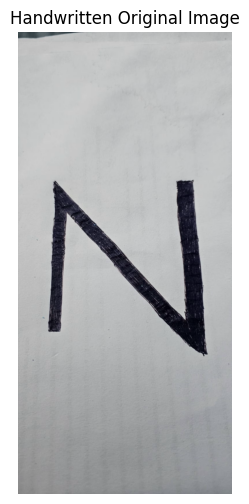

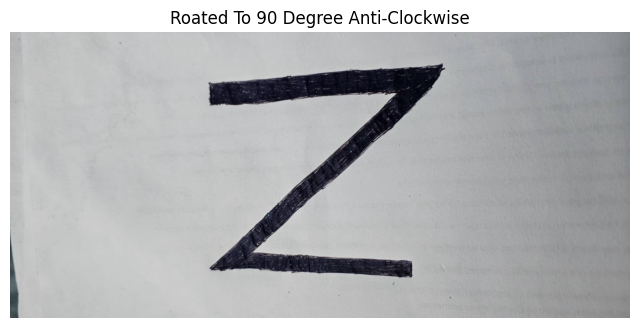

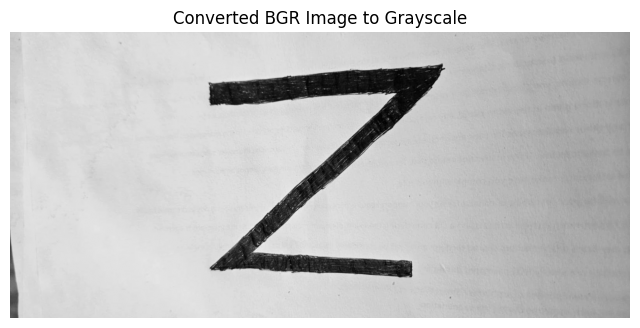

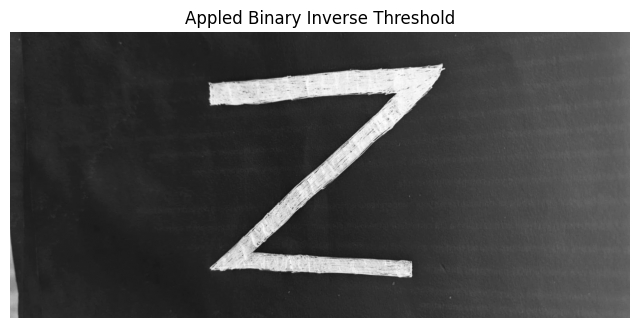

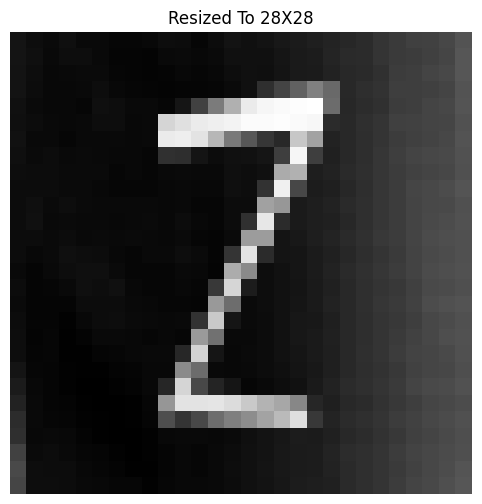

784
67,62,60,63,59,59,57,57,58,62,61,57,61,66,64,66,70,72,75,78,81,84,90,95,99,100,104,113,67,63,59,62,62,59,56,56,55,59,60,58,60,64,64,64,68,71,73,79,83,84,91,95,97,99,103,115,66,62,58,59,60,60,57,56,55,56,58,57,58,62,64,63,67,71,72,77,82,83,88,96,98,102,105,115,66,61,58,58,59,62,58,57,56,55,56,56,57,60,64,87,102,123,146,130,82,86,89,98,98,99,102,113,64,60,58,58,57,63,62,59,59,57,68,100,142,181,224,232,235,237,239,131,81,85,88,97,98,102,104,114,63,61,59,58,59,62,62,58,59,208,216,224,227,230,236,236,237,235,233,84,82,87,91,99,100,102,103,112,65,59,59,57,59,59,59,58,59,224,226,219,186,141,116,92,82,198,171,77,82,86,90,96,99,101,104,113,63,60,61,59,60,59,58,58,57,88,86,67,61,64,65,68,98,232,98,76,82,86,92,98,102,104,106,112,62,61,61,60,60,60,57,58,57,59,60,59,59,63,62,64,177,182,74,77,83,87,92,96,100,102,104,111,61,61,61,60,60,58,57,57,57,58,59,58,58,63,62,89,228,104,73,75,81,86,92,97,103,105,108,114,61,63,60,62,60,59,59,59,59,58,59,57,57,61,61,170,163,71,74,77,83,87,92,97,102,105,106,11

In [ ]:
# Handwritten image pipeline: load a real sample, validate it, rotate and convert to grayscale,
# invert and resize to 28x28, then flatten to a 784-length uint8 bit array for downstream use.

# import necessary libraries for handwritten test sample Image Processing
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Re-Usable Method to Display the loaded Image
def showImage(imageVariable, messageVariable):
    plt.figure(figsize=(8, 6))
    
    # If image has 2 dimensions, treat it as grayscale
    if imageVariable.ndim == 2:
        plt.imshow(imageVariable, cmap='gray')
    else:
        plt.imshow(imageVariable)  # color image
    
    plt.axis('off')
    plt.title(messageVariable)
    plt.show()

# Step:1 - Acquiring one real handwritten test sample Image for validation and Load Handwritten Image
# imgpath = 'C:\GithubRepositoryFolder\cv-assignment-1\my_handwritten_text.png'
imgpath = 'my_handwritten_text.png'
handwrittenimage = cv2.imread(imgpath)

#Checking Proper Loading of the image
if handwrittenimage is None:
    raise FileNotFoundError(f"Either Image not found or could not be read: {imgpath}")
else: showImage(handwrittenimage,"Handwritten Original Image")

# Step:2 - Perform Elementary Operation On Test Image - Rotate Handwritten Test Image 90 Degree Anti-Clockwise and saving it
rotated_handwrittenimage = cv2.rotate(handwrittenimage, cv2.ROTATE_90_COUNTERCLOCKWISE)
showImage(rotated_handwrittenimage,"Roated To 90 Degree Anti-Clockwise")
if cv2.imwrite("C:\GithubRepositoryFolder\cv-assignment-1\rotated_Z.png", rotated_handwrittenimage):
    print("rotated_Z.png saved successfully")
else:
    print("Failed to save rotated_Z.png")


# Step:3 - Perform Elementary Operation On Test Image - Convert BGR Image to Grayscale
grayscale_handwrittenimage = cv2.cvtColor(rotated_handwrittenimage,cv2.COLOR_BGR2GRAY)
showImage(grayscale_handwrittenimage,"Converted BGR Image to Grayscale")

# Step:4 - Convert to binary (thresholding) - Inverts the pixel values of a grayscale handwritten image using OpenCV Function & Displays the inverted image in a window titled "Appled Binary Inverse Threshold".
img_binary = cv2.bitwise_not(grayscale_handwrittenimage)
showImage(img_binary,"Appled Binary Inverse Threshold")

# Step:5 - Perform Elementary Operation On Test Image - Resizing the image to 28×28
resized_handwrittenimage = cv2.resize(img_binary, (28, 28), interpolation=cv2.INTER_AREA)
showImage(resized_handwrittenimage,"Resized To 28X28")

# Step:6 - Flatten to 1D array of length 784 & checking the length of the Bit Array
bit_array = resized_handwrittenimage.flatten().astype(np.uint8)
print(len(bit_array))

# Step:7 - Print as continuous bit string - Convert each bit to string and join with commas
cs_bit = ''
for b in bit_array:
    cs_bit += str(b) + ','
print(cs_bit)



In [23]:
# Load the EMNIST Letters dataset, separate labels and pixel values,
# and reshape flattened image data into 28×28 grayscale images for model training and testing.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Loading EMNIST Letters dataset...")

# Load training data
train_df = pd.read_csv('emnist-letters-train.csv', header=None)
print("Train data loaded. Shape:", train_df.shape)

# Load test data
test_df = pd.read_csv('emnist-letters-test.csv', header=None)
print("Test data loaded. Shape:", test_df.shape)

# Separate labels and images
y_train = train_df.iloc[:, 0].values - 1     # Labels 1-26 → 0-25
X_train = train_df.iloc[:, 1:].values         # Pixel values

y_test = test_df.iloc[:, 0].values - 1
X_test = test_df.iloc[:, 1:].values

# Reshape to 28x28 images
X_train = X_train.reshape(-1, 28, 28)
X_test = X_test.reshape(-1, 28, 28)

print("\nFinal Shapes:")
print("X_train:", X_train.shape)   # (88800, 28, 28)
print("y_train:", y_train.shape)   # (88800,)
print("X_test :", X_test.shape)    # (14800, 28, 28)
print("y_test :", y_test.shape)

Loading EMNIST Letters dataset...
Train data loaded. Shape: (88800, 785)
Test data loaded. Shape: (14801, 785)

Final Shapes:
X_train: (88800, 28, 28)
y_train: (88800,)
X_test : (14801, 28, 28)
y_test : (14801,)


In [24]:
# Sample 15,000 images (change number as per your choice)
np.random.seed(42)   # for reproducibility
sample_size = 15000

indices = np.random.choice(len(X_train), sample_size, replace=False)

X_train = X_train[indices]
y_train = y_train[indices]

print("After sampling:", X_train.shape)

After sampling: (15000, 28, 28)


In [25]:
# Convert to float and normalize to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

print("Normalization done.")

Normalization done.


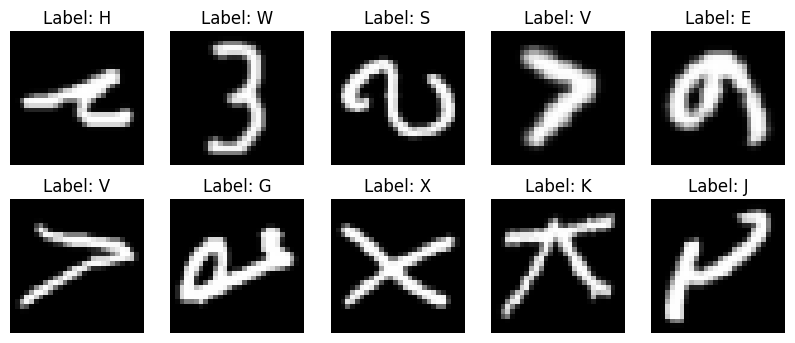

In [26]:
# Show 10 random images
plt.figure(figsize=(10, 4))
for i in range(10):
    idx = np.random.randint(0, len(X_train))
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.title(f"Label: {chr(y_train[idx] + 65)}")  # 0=A, 1=B, ...
    plt.axis('off')
plt.show()

Part 2 – Preprocessing and Feature Extraction
Image processing steps were applied: images were converted to grayscale, contrast was equalized (histogram normalization/equalization), and noise was reduced with Gaussian or median blur. Mid-level features were then extracted (Sobel/Canny edges, contours/connected components, LBP texture, and ORB keypoints where useful), and a compact 3–5‑element feature vector per image was assembled and stored in a feature matrix.

In [27]:
# import necessary libraries
import numpy as np
import cv2

In [28]:
# ORB detector for keypoint extraction
orb = cv2.ORB_create()

In [29]:
def extract_features(img):
    # Convert normalized image to uint8
    img_uint8 = (img * 255).astype(np.uint8)

    # Improve image contrast
    img_eq = cv2.equalizeHist(img_uint8)

    # Reduce noise
    img_blurred = cv2.GaussianBlur(img_eq, (3, 3), 0)

    # Feature 1: Sobel Edge Strength
    sobelx = cv2.Sobel(img_blurred, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img_blurred, cv2.CV_64F, 0, 1, ksize=3)

    sobel_mag = np.sqrt(sobelx**2 + sobely**2)

    f1 = np.mean(sobel_mag) / 255.0

    # Feature 2: Connected Components
    _, binary = cv2.threshold(
        img_blurred,
        80,
        255,
        cv2.THRESH_BINARY
    )

    num_labels, _ = cv2.connectedComponents(binary)

    f2 = num_labels - 1

    # Feature 3: LBP Texture
    lbp = np.zeros_like(img_blurred, dtype=np.float32)

    for i in range(1, 27):
        for j in range(1, 27):

            center = img_blurred[i, j]

            neighbors = [
                img_blurred[i-1, j-1],
                img_blurred[i-1, j],
                img_blurred[i-1, j+1],
                img_blurred[i, j-1],
                img_blurred[i, j+1],
                img_blurred[i+1, j-1],
                img_blurred[i+1, j],
                img_blurred[i+1, j+1]
            ]

            binary_vals = [
                1 if n >= center else 0
                for n in neighbors
            ]

            lbp[i, j] = sum(
                val * (2 ** k)
                for k, val in enumerate(binary_vals)
            )

    f3 = np.mean(lbp) / 255.0

    # Feature 4: Canny Edge Density
    canny = cv2.Canny(img_blurred, 50, 150)

    f4 = np.mean(canny) / 255.0

    # Feature 5: ORB Keypoints
    keypoints = orb.detect(img_blurred, None)

    f5 = len(keypoints)

    # Feature 6: Mean Intensity (after eq)
    f6 = np.mean(img_eq) / 255.0

    # Final feature vector
    feature_vector = np.array([
        f1,
        f2,
        f3,
        f4,
        f5,
        f6
    ])

    return feature_vector

In [30]:
"""sample_features = extract_features(X_train[0])

print("Sample Feature Vector:")
print(sample_features)"""

'sample_features = extract_features(X_train[0])\n\nprint("Sample Feature Vector:")\nprint(sample_features)'

In [31]:
print("Extracting features from training images...")

X_train_features = []

for i in range(len(X_train)):

    vec = extract_features(X_train[i])

    X_train_features.append(vec)

    if (i + 1) % 5000 == 0:
        print(f"Processed {i+1}/{len(X_train)} images")

Extracting features from training images...
Processed 5000/15000 images
Processed 10000/15000 images
Processed 15000/15000 images


In [32]:
X_train_features = np.array(X_train_features)

print("Training Feature Matrix Shape:")
print(X_train_features.shape)

Training Feature Matrix Shape:
(15000, 6)


In [33]:
X_test_features = [
    extract_features(img)
    for img in X_test
]

X_test_features = np.array(X_test_features)

print("Test Feature Matrix Shape:")
print(X_test_features.shape)

Test Feature Matrix Shape:
(14801, 6)


In [34]:
np.save('X_train_features_5.npy', X_train_features)
np.save('X_test_features_5.npy', X_test_features)

np.save('y_train.npy', y_train)
np.save('y_test.npy', y_test)

print("Features Saved Successfully!")

Features Saved Successfully!


In [35]:
print("Sample Feature Vector:", X_train_features[0])

Sample Feature Vector: [0.935045   1.         0.52599543 0.19260204 0.         0.21189976]


In [36]:
#Part 3 - Model Training
import numpy as np

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score

print("\n--- PART 3 : MODEL TRAINING ---")

# Load extracted features
X_train = np.load("X_train_features_5.npy")
X_test = np.load("X_test_features_5.npy")

y_train = np.load("y_train.npy")
y_test = np.load("y_test.npy")

# Store trained models
trained_payload = {}

# -----------------------------
# 1. k-NN
# -----------------------------
print("\nTraining k-NN...")
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

knn_preds = knn_model.predict(X_test)
knn_acc = accuracy_score(y_test, knn_preds)

print(f"k-NN Accuracy: {knn_acc:.4f}")

trained_payload["kNN"] = knn_model

# -----------------------------
# 2. SVM
# -----------------------------
print("\nTraining SVM...")
svm_model = SVC(kernel='rbf')

svm_model.fit(X_train, y_train)

svm_preds = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, svm_preds)

print(f"SVM Accuracy: {svm_acc:.4f}")

trained_payload["SVM"] = svm_model

# -----------------------------
# 3. Random Forest
# -----------------------------
print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)

print(f"Random Forest Accuracy: {rf_acc:.4f}")

trained_payload["Random_Forest"] = rf_model

# -----------------------------
# 4. Logistic Regression
# -----------------------------
print("\nTraining Logistic Regression...")
lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_preds)

print(f"Logistic Regression Accuracy: {lr_acc:.4f}")

trained_payload["Logistic_Regression"] = lr_model

# Save trained models
np.save("trained_payload.npy", trained_payload)

print("\nAll models trained successfully.")
print("trained_payload.npy saved successfully.")


--- PART 3 : MODEL TRAINING ---

Training k-NN...
k-NN Accuracy: 0.2040

Training SVM...
SVM Accuracy: 0.1578

Training Random Forest...
Random Forest Accuracy: 0.2149

Training Logistic Regression...
Logistic Regression Accuracy: 0.1762

All models trained successfully.
trained_payload.npy saved successfully.


In [37]:
# Save evaluation split before validation metrics block

evaluation_split = {
    "X_train": X_train,
    "X_test": X_test,
    "y_train": y_train,
    "y_test": y_test
}

np.save("evaluation_split.npy", evaluation_split)

print("evaluation_split.npy saved successfully.")

evaluation_split.npy saved successfully.


In [38]:
import os
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
print("\n--- [DEV 4] Starting Validation Metrics Report ---")
# Load trained models and evaluation data
trained_payload = np.load('trained_payload.npy', allow_pickle=True).item()
eval_data = np.load('evaluation_split.npy', allow_pickle=True).item()
X_test = eval_data["X_test"]
y_test = eval_data["y_test"]
print("\n--- FINAL SCORING METRICS SUMMARY REPORT ---")
# Evaluate each model
for name, clf in trained_payload.items():
    preds = clf.predict(X_test)
    # Metrics
    acc = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds, average='macro',  zero_division=0)
    recall = recall_score(y_test, preds, average='macro', zero_division=0)
    f1 = f1_score(y_test, preds, average='macro', zero_division=0)
    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    print(f"\nAlgorithm: {name}")
    print(f"Test Accuracy  : {acc:.4f}")
    print(f"Precision      : {precision:.4f}")
    print(f"Recall         : {recall:.4f}")
    print(f"F1-Macro Score : {f1:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_test, preds, zero_division=0))
# Handwritten Letter existance Check
print("\n--- HANDWRITTEN LETTER PREDICTION CHECK ---")
if not os.path.exists("my_handwritten_letter.png"):
    print("-> Please place your handwritten image file as 'my_handwritten_letter.png'")
else:
    print("-> Handwritten image found successfully.")
    print("-> Standby for external handwritten prediction testing module.")
# Note: The actual prediction code for the handwritten letter will be implemented in the next development phase.


--- [DEV 4] Starting Validation Metrics Report ---

--- FINAL SCORING METRICS SUMMARY REPORT ---

Algorithm: kNN
Test Accuracy  : 0.2040
Precision      : 0.1740
Recall         : 0.1409
F1-Macro Score : 0.1518

Confusion Matrix:
[[180  63  24  44  90  17  42  10   2   2  30   5  30  15  58  16  27  20
   23   6   5  11  17  38  10  15   0]
 [ 88 154  21  93  27  20  66  16   2  10  15   4  18   7  12  38  88  12
   10  14   1   9  22  13  25  15   0]
 [ 42  24 183  25  28  48  12  41   2  27  17   3  15  55  44   4   4  37
   21  15  76  26  18   9  14  10   0]
 [ 96 109  36  97  19  30  52  20   2  22  20   2  28   8  18  58  21   9
   14  11   8  16  30  17  33  24   0]
 [151  48  34  27 182  17  31  12   3   4  23   2  26  14  59   5  14  15
   35   1  16  13   7  38   6  17   0]
 [ 35  48  82  56  13 146  17  73   3  39  24   6  20  17   3  19   3  17
   10  48  16  28   8  16  46   7   0]
 [104 106  19  98  45  17  73  12   2  10  17   1  25   8  28  25  56   8
   12   7   2   9  

Handwritten image loaded successfully.

--- NORMALIZED PIXEL VALUES ---
[[0.25490196 0.25098039 0.24313725 0.23921569 0.24313725 0.24313725
  0.24313725 0.25490196 0.23529412 0.25098039 0.23921569 0.23137255
  0.25098039 0.22745098 0.24705882 0.23921569 0.22745098 0.23921569
  0.23921569 0.23529412 0.24313725 0.25098039 0.23529412 0.25098039
  0.25882353 0.27058824 0.29019608 0.2627451 ]
 [0.24705882 0.24313725 0.23137255 0.21176471 0.23921569 0.23921569
  0.23921569 0.22352941 0.22352941 0.21568627 0.21176471 0.23529412
  0.21960784 0.21176471 0.22352941 0.23529412 0.25882353 0.23921569
  0.24313725 0.24313725 0.24313725 0.22745098 0.23921569 0.23137255
  0.24313725 0.25490196 0.25098039 0.23529412]
 [0.24313725 0.23137255 0.23529412 0.23921569 0.23137255 0.21568627
  0.21960784 0.21960784 0.21960784 0.22352941 0.21960784 0.21176471
  0.23137255 0.24313725 0.23921569 0.23529412 0.22745098 0.23137255
  0.23137255 0.24313725 0.24313725 0.23921569 0.24313725 0.22352941
  0.23137255 0.227

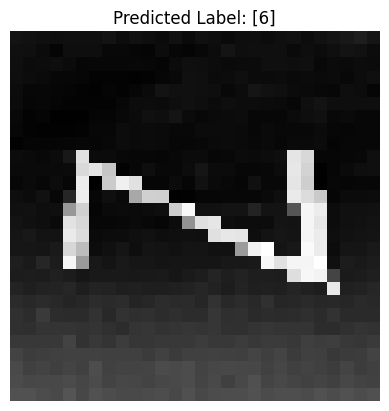

In [39]:
# ---------------------------------------------
# HANDWRITTEN LETTER PREDICTION MODULE
# ---------------------------------------------

import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = "my_handwritten_text.png"

# Load image
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Image not found.")

else:

    print("Handwritten image loaded successfully.")

    # Resize
    resized = cv2.resize(img, (28, 28))

    # Invert colors
    resized = 255 - resized

    # Normalize
    normalized = resized / 255.0

    # Print full scanned pixel matrix
    print("\n--- NORMALIZED PIXEL VALUES ---")
    print(normalized)

    # Print flattened values
    flattened = normalized.flatten()

    print("\n--- FLATTENED PIXEL VALUES ---")
    print(flattened)

    print("\nTotal Values Scanned:", len(flattened))

    # Feature extraction
    feature_vector = [
        np.mean(normalized),
        np.std(normalized),
        np.max(normalized),
        np.min(normalized),
        np.sum(normalized),
        np.median(normalized)
    ]

    print("\n--- EXTRACTED FEATURES ---")
    print("Mean      :", feature_vector[0])
    print("Std Dev   :", feature_vector[1])
    print("Max Value :", feature_vector[2])
    print("Min Value :", feature_vector[3])
    print("Pixel Sum :", feature_vector[4])
    print("Median    :", feature_vector[5])

    handwritten_features = np.array(feature_vector).reshape(1, -1)

    print("\nFeature Shape:", handwritten_features.shape)

    # Prediction
    clf = trained_payload["Random_Forest"]

    predicted_label = clf.predict(handwritten_features)

    print("\nPredicted Character Label:", predicted_label)

    # Display image
    plt.imshow(resized, cmap='gray')
    plt.title(f"Predicted Label: {predicted_label}")
    plt.axis("off")
    plt.show()